# Shazam Robustness — Results Analysis

Reads `results/shazam_eval_combined.csv`, which merges the additive-noise sweep and the transform sweep into a single file. Produces:

- Overall outcome breakdown (correct / wrong-ID / no-ID)
- Top-1 accuracy and false-positive rate by condition, split by augmentation category
- Per-genre accuracy (bar + heatmap)
- Genre × condition heatmaps per augmentation type
- Identification latency distribution and by condition
- Score / confidence distributions by outcome
- Genre confusion analysis (when wrong, what genre did it pick?)

**Augmentation types and `db_severity` meaning:**

| aug_type | db_severity | Meaning |
|---|---|---|
| `crowd_noise` | 0 / 10 / 20 | SNR in dB (0 = most noise) |
| `street_noise` | 0 / 10 / 20 | SNR in dB |
| `white_noise` | 0 / 10 / 20 | SNR in dB |
| `lofi_filter` | 1 / 2 / 3 | Severity (L1=300–8kHz, L2=400–6kHz, L3=500–4kHz) |
| `pitch_shift_up` | 1 / 2 / 3 | Semitones up |
| `pitch_shift_down` | 1 / 2 / 3 | Semitones down |

**Convention used throughout:**
- `correct == 'yes'` → **TRUE POSITIVE** (matched the right song)
- `identified == 'yes' & correct == 'no'` → **FALSE POSITIVE** (confidently picked a wrong song)
- `identified == 'no'` → **REJECT** (matcher returned None; failed safely)

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

CSV_PATH = Path("results/shazam_eval_combined.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"{CSV_PATH} not found.")

df = pd.read_csv(CSV_PATH)
df["db_severity"] = df["db_severity"].astype(int)

# Outcome label per row.
def outcome(row):
    if row["identified"] == "no":
        return "reject"
    return "correct" if row["correct"] == "yes" else "false_positive"

df["outcome"] = df.apply(outcome, axis=1)

_NOISE_TYPES = {"crowd_noise", "street_noise", "white_noise"}
_TRANSFORM_TYPES = {"pitch_shift_up", "pitch_shift_down", "lofi_filter"}
df["aug_category"] = df["aug_type"].apply(
    lambda x: "noise" if x in _NOISE_TYPES else "transform"
)

AUG_LABELS = {
    "crowd_noise":     "Crowd Noise",
    "street_noise":    "Street Noise",
    "white_noise":     "White Noise",
    "lofi_filter":     "Lo-Fi Filter",
    "pitch_shift_up":  "Pitch Up",
    "pitch_shift_down":"Pitch Down",
}
df["aug_label"] = df["aug_type"].map(AUG_LABELS).fillna(df["aug_type"])

# Canonical display order: noise types first, then transforms.
AUG_TYPE_ORDER  = ["crowd_noise", "street_noise", "white_noise",
                   "lofi_filter", "pitch_shift_up", "pitch_shift_down"]
AUG_LABEL_ORDER = [AUG_LABELS[t] for t in AUG_TYPE_ORDER]

# Genre of the wrongly-picked match. GTZAN convention: 'genre.NNNNN.wav'.
df["top_match_genre"] = (
    df["top_match_name"].fillna("").str.split(".").str[0].replace("", np.nan)
)

print(f"Loaded {len(df):,} rows ({df[df['aug_category']=='noise'].shape[0]:,} noise, "
      f"{df[df['aug_category']=='transform'].shape[0]:,} transform)")
df.groupby(["aug_label", "db_severity"]).size().rename("n").reset_index()

Loaded 17,982 rows (8,991 noise, 8,991 transform)


,aug_label,db_severity,n
0,Crowd Noise,0,999
1,Crowd Noise,10,999
2,Crowd Noise,20,999
3,Lo-Fi Filter,1,999
4,Lo-Fi Filter,2,999
5,Lo-Fi Filter,3,999
6,Pitch Down,1,999
7,Pitch Down,2,999
8,Pitch Down,3,999
9,Pitch Up,1,999


## 1. Coverage sanity check
How many rows per (aug_type, db_severity) cell? Should be ~999 per cell.

In [3]:
coverage = df.pivot_table(
    index="aug_label", columns="db_severity", values="filename", aggfunc="count"
).fillna(0).astype(int).reindex(AUG_LABEL_ORDER)
coverage.index.name = "aug_type"
coverage.columns.name = "db_severity"
coverage

db_severity,0,1,2,3,10,20
aug_type,,,,,,
Crowd Noise,999,0,0,0,999,999
Street Noise,999,0,0,0,999,999
White Noise,999,0,0,0,999,999
Lo-Fi Filter,0,999,999,999,0,0
Pitch Up,0,999,999,999,0,0
Pitch Down,0,999,999,999,0,0


## 2. Overall outcome breakdown
Three-way split across the entire run.


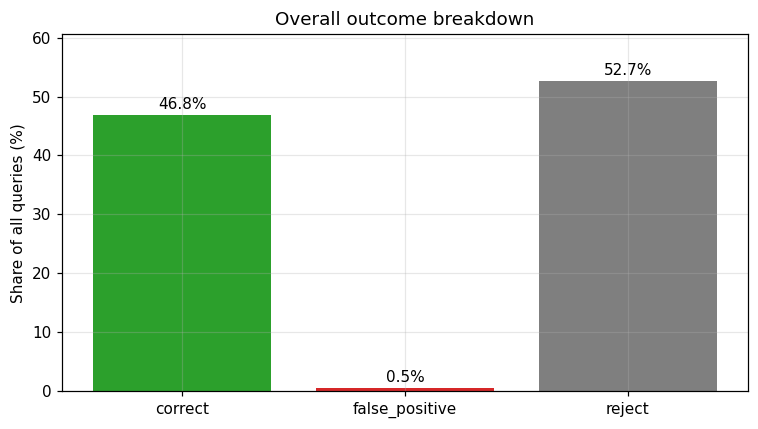

outcome
correct           46.83
false_positive     0.48
reject            52.69
Name: proportion, dtype: float64


In [4]:
overall = df["outcome"].value_counts(normalize=True).reindex(
    ["correct", "false_positive", "reject"]
).fillna(0) * 100

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ca02c", "#d62728", "#7f7f7f"]
bars = ax.bar(overall.index, overall.values, color=colors)
for b, v in zip(bars, overall.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}%",
            ha="center", va="bottom")
ax.set_ylabel("Share of all queries (%)")
ax.set_title("Overall outcome breakdown")
ax.set_ylim(0, max(overall.values) * 1.15)
plt.tight_layout()
plt.show()

print(overall.round(2))

### 2a. Outcome breakdown — noise vs transform
Side-by-side: how does the overall outcome split differ between additive noise and musical transforms?

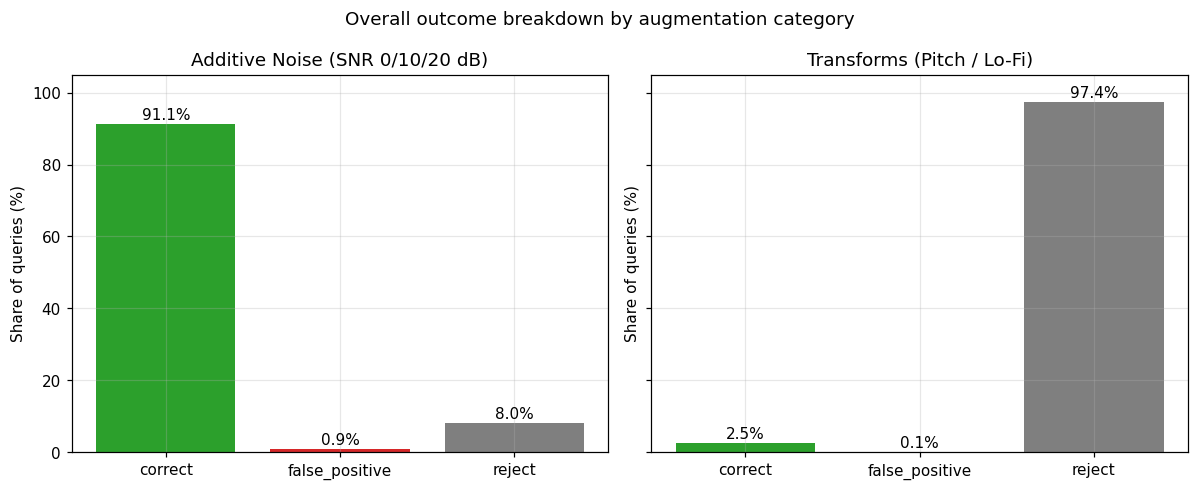

outcome,correct,false_positive,reject
aug_category,,,
noise,91.15,0.89,7.96
transform,2.51,0.08,97.41


In [5]:
outcomes = ["correct", "false_positive", "reject"]
colors_map = {"correct": "#2ca02c", "false_positive": "#d62728", "reject": "#7f7f7f"}

by_category = (
    df.groupby("aug_category")["outcome"]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
      .reindex(columns=outcomes, fill_value=0) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, cat in zip(axes, ["noise", "transform"]):
    vals = by_category.loc[cat] if cat in by_category.index else pd.Series(0, index=outcomes)
    bars = ax.bar(outcomes, vals.values, color=[colors_map[o] for o in outcomes])
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}%",
                ha="center", va="bottom")
    label = "Additive Noise (SNR 0/10/20 dB)" if cat == "noise" else "Transforms (Pitch / Lo-Fi)"
    ax.set_title(label)
    ax.set_ylabel("Share of queries (%)")
    ax.set_ylim(0, 105)

fig.suptitle("Overall outcome breakdown by augmentation category")
plt.tight_layout()
plt.show()
by_category.round(2)

## 3. Performance by condition
Top-1 accuracy per aug_type across db_severity levels. Noise types (left) and transforms (right) are plotted separately because their x-axis units differ (dB vs severity level).

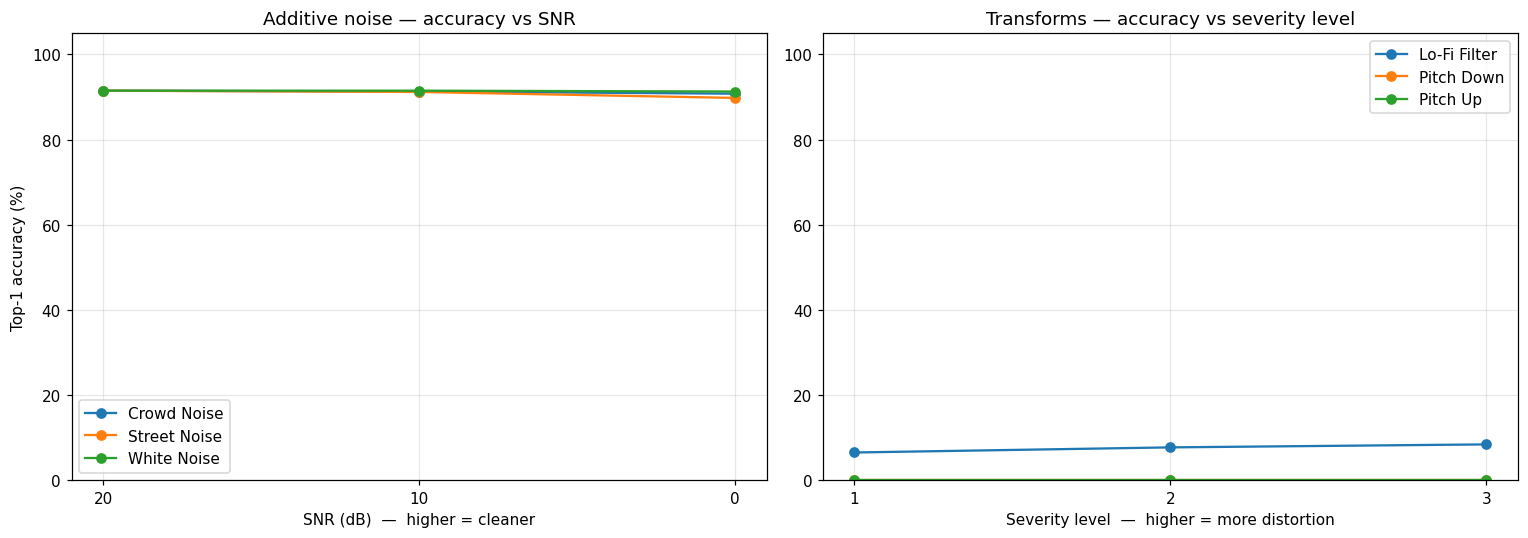

,aug_label,aug_category,db_severity,accuracy,false_positive,reject,n
0,Crowd Noise,noise,0,90.79,0.7,8.51,999.0
1,Crowd Noise,noise,10,91.29,0.9,7.81,999.0
2,Crowd Noise,noise,20,91.49,1.1,7.41,999.0
3,Lo-Fi Filter,transform,1,6.51,0.2,93.29,999.0
4,Lo-Fi Filter,transform,2,7.71,0.2,92.09,999.0
5,Lo-Fi Filter,transform,3,8.41,0.3,91.29,999.0
6,Pitch Down,transform,1,0.00,0.0,100.00,999.0
7,Pitch Down,transform,2,0.00,0.0,100.00,999.0
8,Pitch Down,transform,3,0.00,0.0,100.00,999.0
9,Pitch Up,transform,1,0.00,0.0,100.00,999.0


In [6]:
def rate(g, label):
    return (g["outcome"] == label).mean() * 100

agg = df.groupby(["aug_type", "aug_label", "aug_category", "db_severity"]).apply(
    lambda g: pd.Series({
        "accuracy": rate(g, "correct"),
        "false_positive": rate(g, "false_positive"),
        "reject": rate(g, "reject"),
        "n": len(g),
    }),
    include_groups=False,
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: noise types (x-axis = SNR dB, higher = cleaner)
noise_agg = agg[agg["aug_category"] == "noise"]
for label, sub in noise_agg.groupby("aug_label"):
    sub = sub.sort_values("db_severity")
    axes[0].plot(sub["db_severity"], sub["accuracy"], marker="o", label=label)
axes[0].set_title("Additive noise — accuracy vs SNR")
axes[0].set_xlabel("SNR (dB)  —  higher = cleaner")
axes[0].set_ylabel("Top-1 accuracy (%)")
axes[0].set_xticks(sorted(noise_agg["db_severity"].unique()))
axes[0].invert_xaxis()
axes[0].set_ylim(0, 105)
axes[0].legend()

# Right: transforms (x-axis = severity level, higher = more distortion)
tx_agg = agg[agg["aug_category"] == "transform"]
for label, sub in tx_agg.groupby("aug_label"):
    sub = sub.sort_values("db_severity")
    axes[1].plot(sub["db_severity"], sub["accuracy"], marker="o", label=label)
axes[1].set_title("Transforms — accuracy vs severity level")
axes[1].set_xlabel("Severity level  —  higher = more distortion")
axes[1].set_xticks(sorted(tx_agg["db_severity"].unique()))
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.tight_layout()
plt.show()
agg.drop(columns=["aug_type"]).round(2)

### 3a. Stacked outcome composition per aug_type
One panel per augmentation type showing how the correct / false-positive / reject split changes across db_severity.

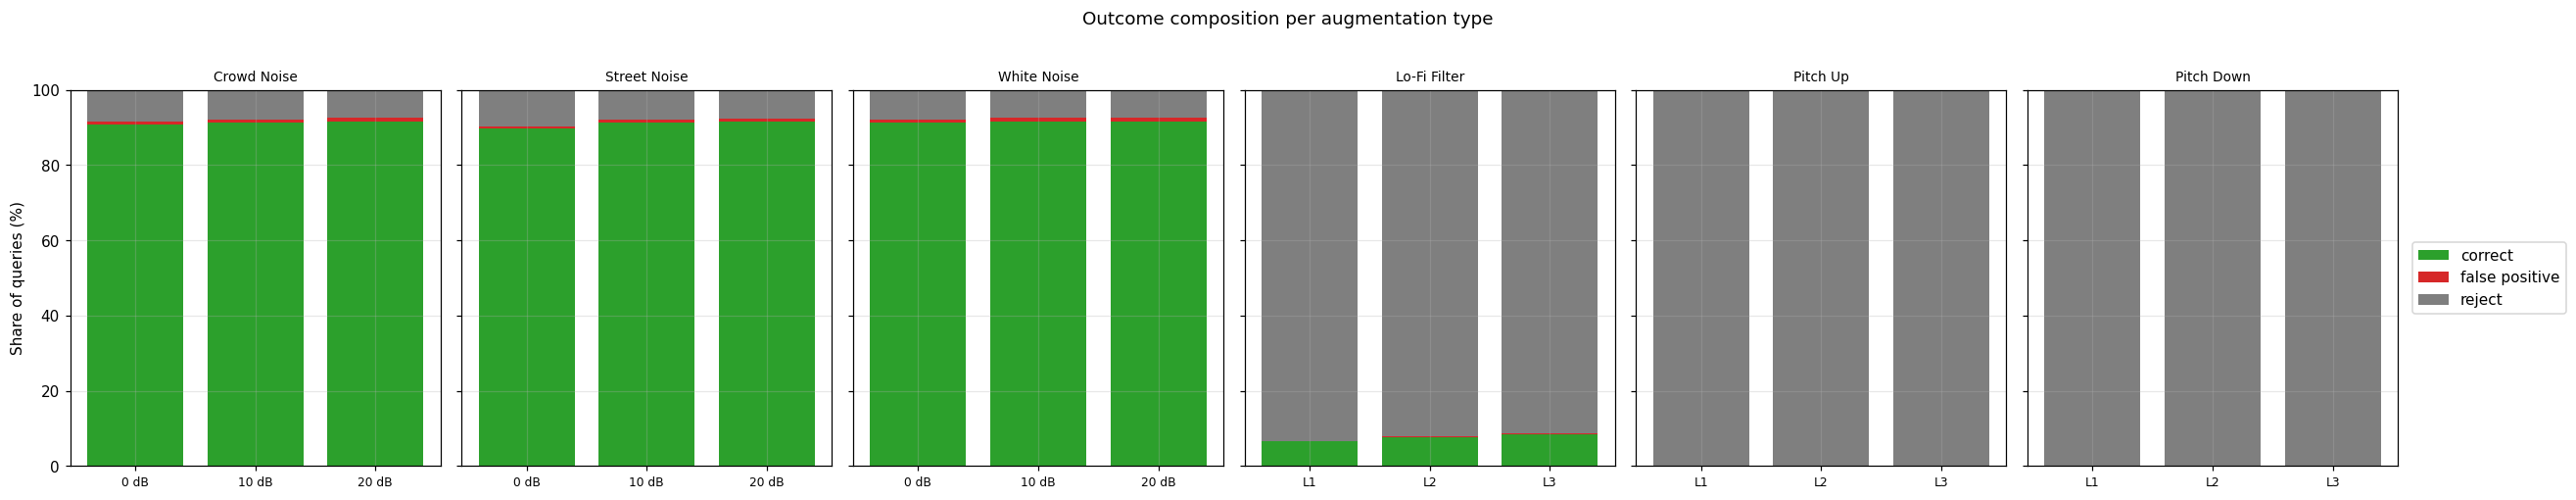

In [7]:
fig, axes = plt.subplots(1, len(AUG_LABEL_ORDER), figsize=(4 * len(AUG_LABEL_ORDER), 4.5),
                          sharey=True)

for ax, al in zip(axes, AUG_LABEL_ORDER):
    cat = df[df["aug_label"] == al]["aug_category"].iloc[0]
    sub_agg = agg[agg["aug_label"] == al].sort_values("db_severity")
    levels = sub_agg["db_severity"].tolist()
    x = np.arange(len(levels))

    ax.bar(x, sub_agg["accuracy"],   label="correct",        color="#2ca02c")
    ax.bar(x, sub_agg["false_positive"], bottom=sub_agg["accuracy"],
           label="false positive", color="#d62728")
    ax.bar(x, sub_agg["reject"],
           bottom=sub_agg["accuracy"] + sub_agg["false_positive"],
           label="reject",          color="#7f7f7f")

    ax.set_title(al, fontsize=9)
    ax.set_xticks(x)
    x_labels = [f"{l} dB" for l in levels] if cat == "noise" else [f"L{l}" for l in levels]
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_ylim(0, 100)

axes[0].set_ylabel("Share of queries (%)")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.suptitle("Outcome composition per augmentation type", y=1.02)
plt.tight_layout()
plt.show()

## 4. Per-genre accuracy
Some genres (e.g. classical) have more transient/percussive content than others. This shows whether the fingerprinter favours certain genres.

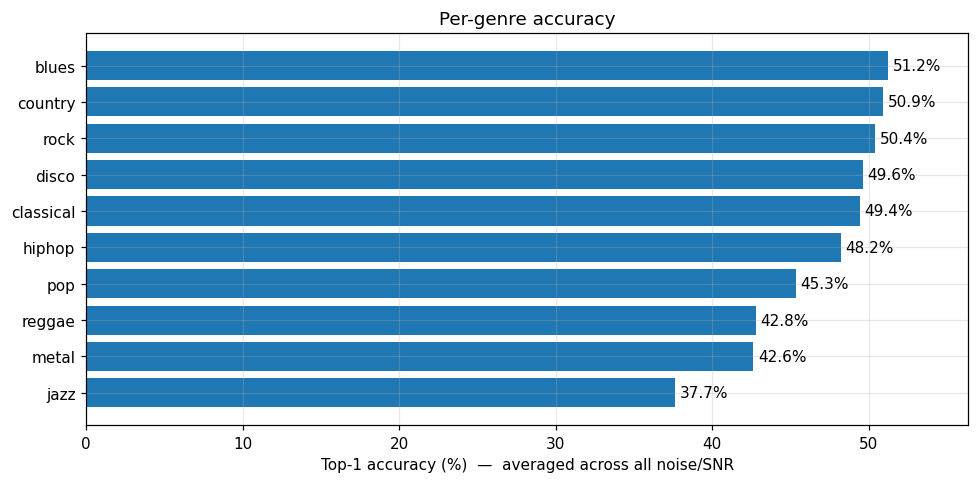

In [8]:
genre_acc = (
    df.groupby("genre")["outcome"]
      .apply(lambda s: (s == "correct").mean() * 100)
      .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(genre_acc.index, genre_acc.values, color="#1f77b4")
for b, v in zip(bars, genre_acc.values):
    ax.text(v + 0.3, b.get_y() + b.get_height() / 2,
            f"{v:.1f}%", va="center")
ax.set_xlabel("Top-1 accuracy (%)  \u2014  averaged across all noise/SNR")
ax.set_title("Per-genre accuracy")
ax.set_xlim(0, max(genre_acc.values) * 1.1)
plt.tight_layout()
plt.show()

### 4a. Per-genre accuracy split by db_severity
Averaged across all augmentation types within each category (noise / transform).

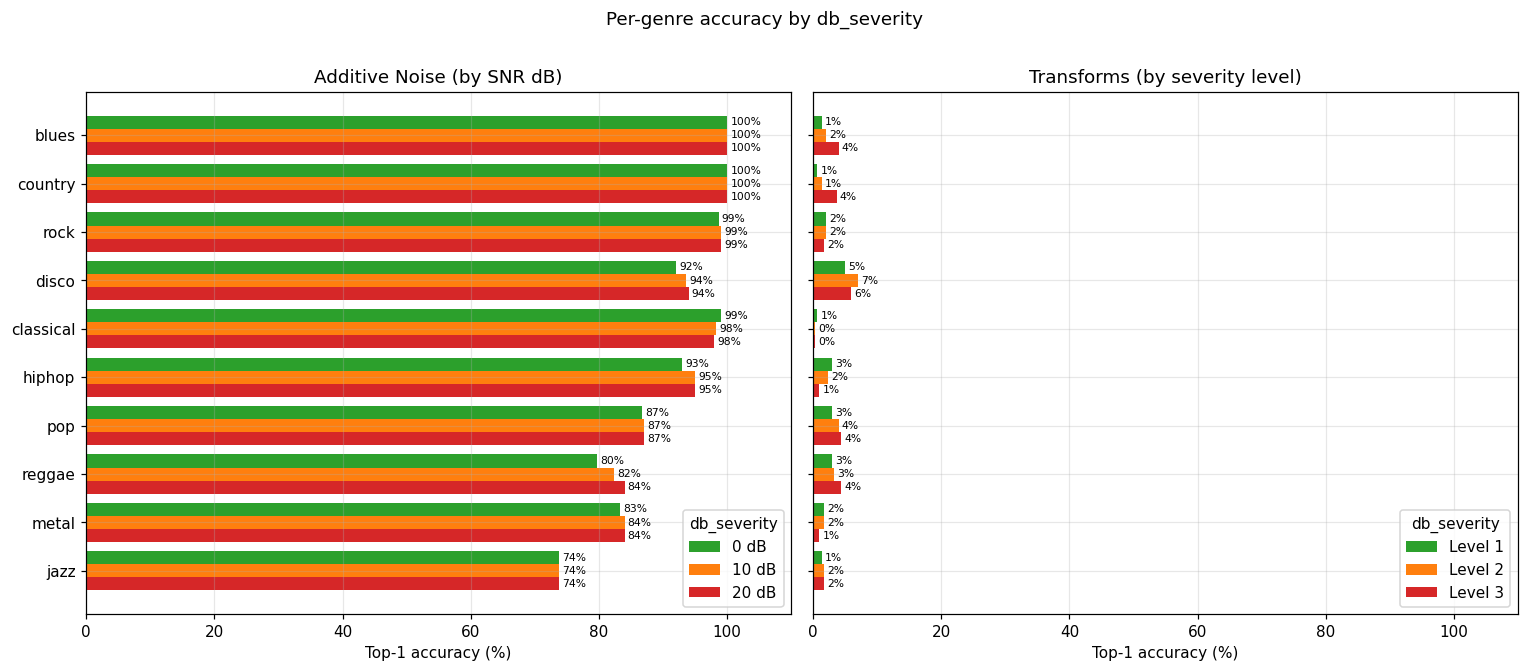

In [9]:
genre_order = (
    df.groupby("genre")["outcome"]
      .apply(lambda s: (s == "correct").mean())
      .sort_values()
      .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, cat, title in zip(
    axes,
    ["noise", "transform"],
    ["Additive Noise (by SNR dB)", "Transforms (by severity level)"]
):
    sub = df[df["aug_category"] == cat]
    lvls = sorted(sub["db_severity"].unique())
    genre_lvl = (
        sub.groupby(["genre", "db_severity"])["outcome"]
           .apply(lambda s: (s == "correct").mean() * 100)
           .unstack("db_severity")
           .reindex(genre_order)
    )
    y = np.arange(len(genre_order))
    bar_height = 0.27
    palette = {lvls[0]: "#2ca02c", lvls[1]: "#ff7f0e", lvls[2]: "#d62728"}
    for i, lv in enumerate(lvls):
        offset = (i - 1) * bar_height
        vals = genre_lvl[lv].values
        label = f"{lv} dB" if cat == "noise" else f"Level {lv}"
        bars = ax.barh(y - offset, vals, bar_height,
                       label=label, color=palette.get(lv, "#1f77b4"))
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(v + 0.5, b.get_y() + b.get_height() / 2,
                        f"{v:.0f}%", va="center", fontsize=7)
    ax.set_yticks(y)
    ax.set_yticklabels(genre_order)
    ax.set_xlabel("Top-1 accuracy (%)")
    ax.set_title(title)
    ax.set_xlim(0, 110)
    ax.legend(title="db_severity", loc="lower right")

fig.suptitle("Per-genre accuracy by db_severity", y=1.01)
plt.tight_layout()
plt.show()

## 5. Genre × db_severity heatmaps (one panel per aug_type)
Where does each augmentation type hurt which genres the most?

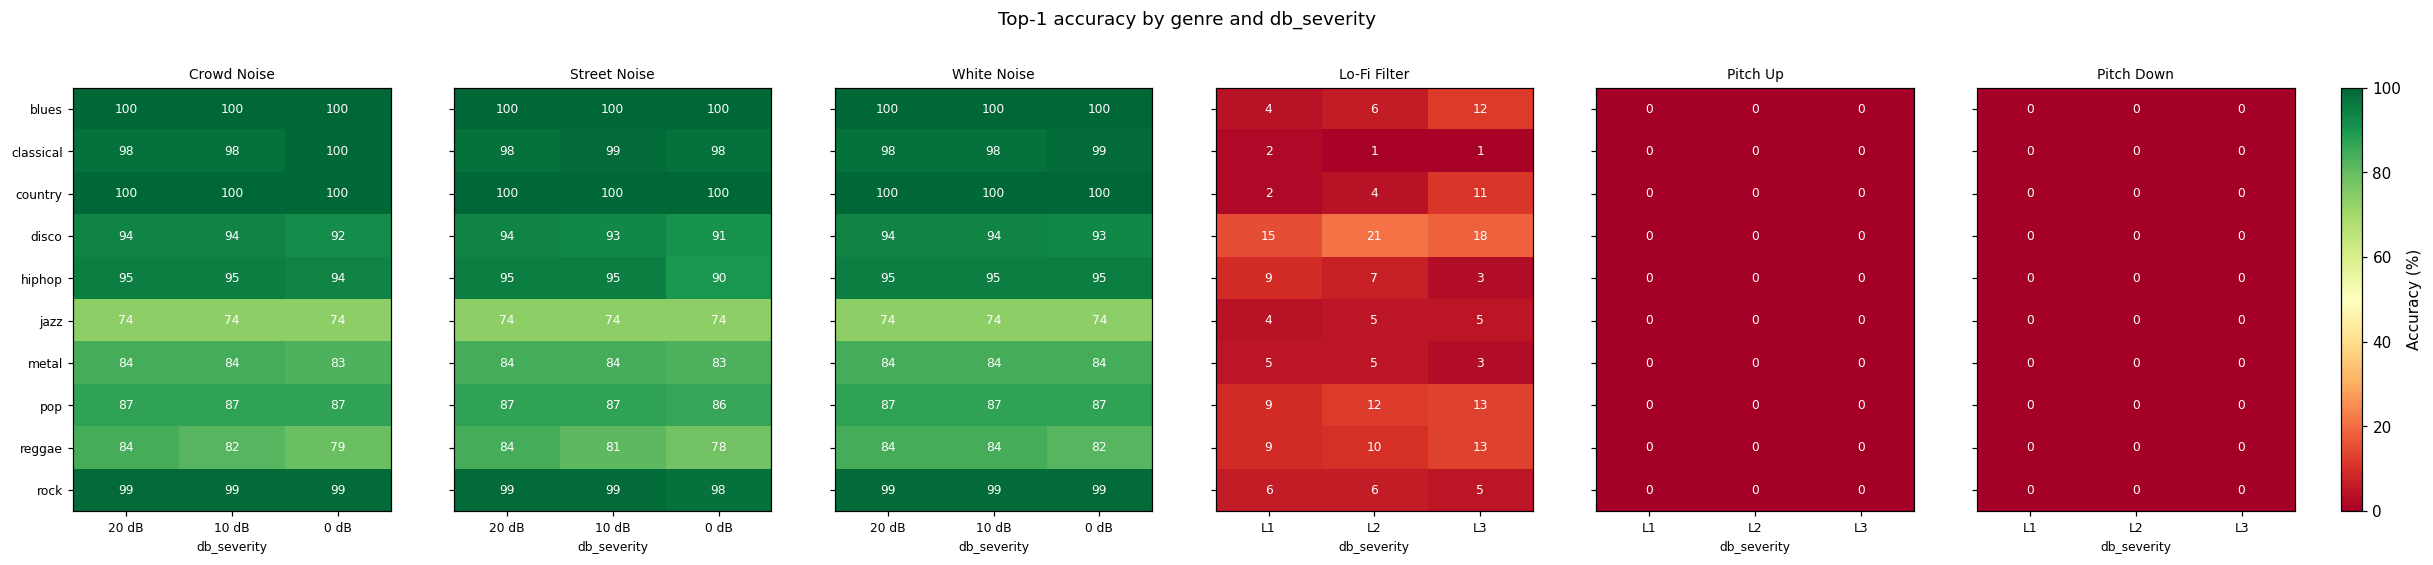

In [10]:
aug_types_ordered = ["crowd_noise", "street_noise", "white_noise",
                      "lofi_filter", "pitch_shift_up", "pitch_shift_down"]

fig, axes = plt.subplots(1, len(aug_types_ordered),
                          figsize=(4.5 * len(aug_types_ordered), 5), sharey=True)

cmap = "RdYlGn"
im = None

for ax, at in zip(axes, aug_types_ordered):
    cat = "noise" if at in _NOISE_TYPES else "transform"
    sub = df[df["aug_type"] == at]
    pivot = sub.pivot_table(
        index="genre", columns="db_severity",
        values="outcome", aggfunc=lambda s: (s == "correct").mean() * 100,
    ).reindex(columns=sorted(sub["db_severity"].unique(),
                              reverse=(cat == "noise")))  # SNR: high→low; level: low→high

    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=0, vmax=100)
    col_labels = ([f"{c} dB" for c in pivot.columns] if cat == "noise"
                  else [f"L{c}" for c in pivot.columns])
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(col_labels, fontsize=8)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(AUG_LABELS.get(at, at), fontsize=9)
    ax.set_xlabel("db_severity", fontsize=8)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                        color="black" if 30 < v < 70 else "white", fontsize=8)
    ax.grid(False)

if im is not None:
    fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label="Accuracy (%)")
fig.suptitle("Top-1 accuracy by genre and db_severity", y=1.02)
plt.show()

## 6. Identification latency
Wall-clock time per `identify_audio()` call. Distribution overall, then by SNR/noise.

/var/folders/w1/dc0wdw412vg246yv8q6q4pnw0000gn/T/ipykernel_42595/2852160132.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=labels, showfliers=False)


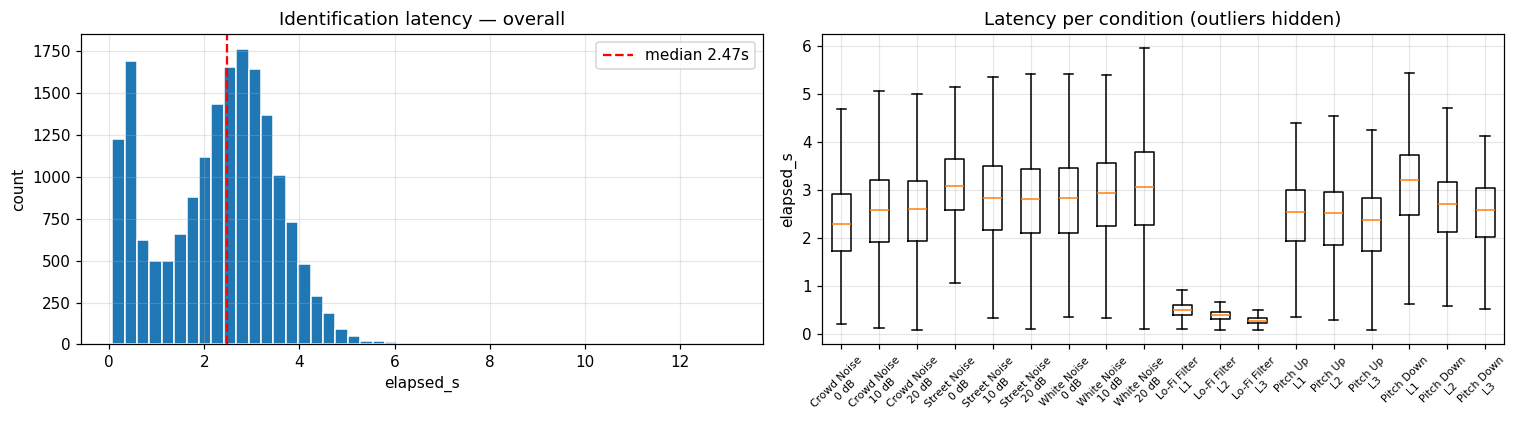

count    17982.000
mean         2.290
std          1.232
min          0.069
25%          1.350
50%          2.474
75%          3.158
max         13.088
Name: elapsed_s, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) overall histogram
axes[0].hist(df["elapsed_s"], bins=50, color="#1f77b4", edgecolor="white")
med = df["elapsed_s"].median()
axes[0].axvline(med, color="red", linestyle="--", label=f"median {med:.2f}s")
axes[0].set_xlabel("elapsed_s")
axes[0].set_ylabel("count")
axes[0].set_title("Identification latency — overall")
axes[0].legend()

# (b) box per condition
conditions = [(at, lv)
              for at in aug_types_ordered
              for lv in sorted(df[df["aug_type"] == at]["db_severity"].unique())]
cat_of = {at: ("noise" if at in _NOISE_TYPES else "transform") for at in aug_types_ordered}
labels = [f"{AUG_LABELS.get(at, at)}\n{'%d dB' % lv if cat_of[at]=='noise' else 'L%d' % lv}"
          for at, lv in conditions]
data = [df[(df["aug_type"] == at) & (df["db_severity"] == lv)]["elapsed_s"].values
        for at, lv in conditions]
axes[1].boxplot(data, labels=labels, showfliers=False)
axes[1].set_ylabel("elapsed_s")
axes[1].set_title("Latency per condition (outliers hidden)")
axes[1].tick_params(axis="x", rotation=45, labelsize=7)

plt.tight_layout()
plt.show()
print(df["elapsed_s"].describe().round(3))

### 6a. Latency vs outcome
Do rejects take longer than hits? (Often they do — they exhaust the matcher before bailing.)

/var/folders/w1/dc0wdw412vg246yv8q6q4pnw0000gn/T/ipykernel_42595/2618948641.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups, showfliers=False,


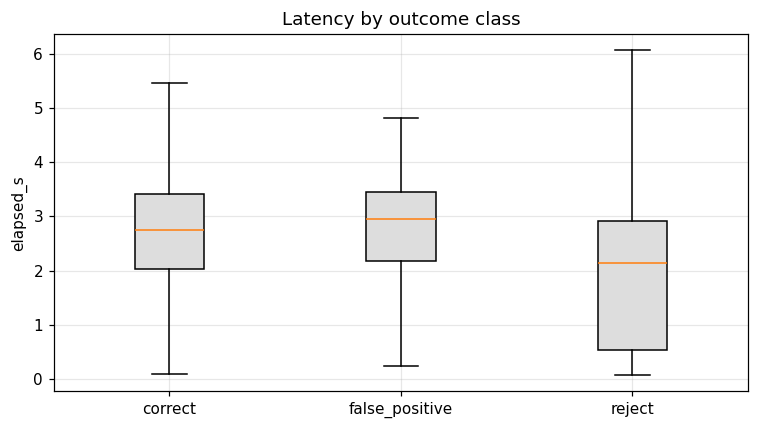

,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
correct,8421.0,2.694,1.086,0.078,2.025,2.758,3.407,13.088
false_positive,87.0,2.774,1.066,0.229,2.167,2.959,3.458,4.829
reject,9474.0,1.926,1.242,0.069,0.529,2.138,2.918,8.618


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
groups = ["correct", "false_positive", "reject"]
data = [df[df["outcome"] == g]["elapsed_s"].values for g in groups]
ax.boxplot(data, labels=groups, showfliers=False,
           patch_artist=True,
           boxprops=dict(facecolor="#dddddd"))
ax.set_ylabel("elapsed_s")
ax.set_title("Latency by outcome class")
plt.tight_layout()
plt.show()

df.groupby("outcome")["elapsed_s"].describe().round(3)

## 7. Confidence / score distributions
Among rows where the matcher *did* identify something, are wrong picks lower-confidence than right ones? If yes, raising `ID_MIN_*` thresholds would convert false positives into rejects.

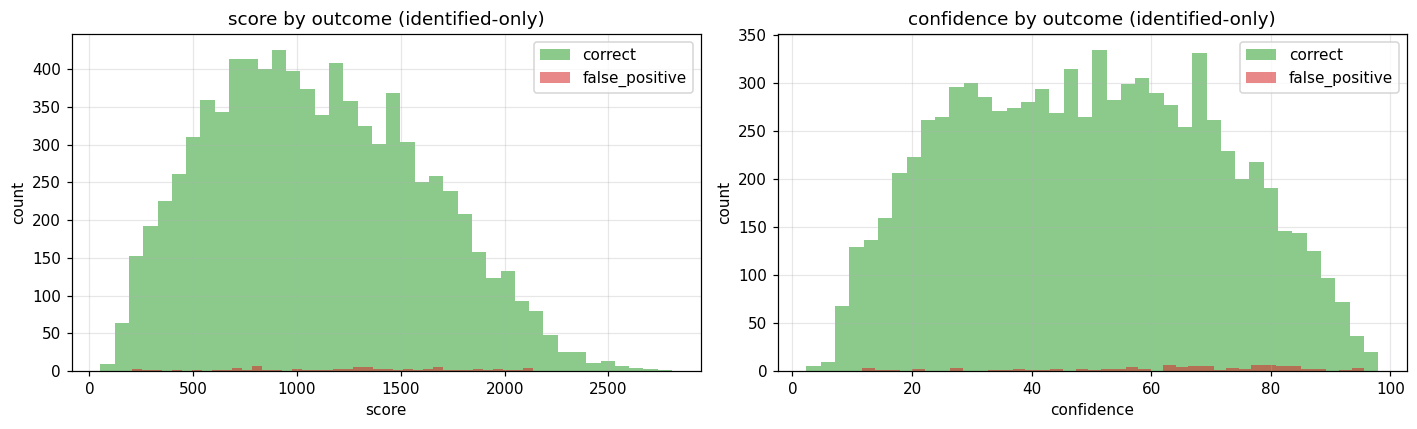

score                                                         \
                 count     mean     std    min    25%     50%     75%     max   
outcome                                                                         
correct         8421.0  1102.24  509.31   53.0  703.0  1060.0  1472.0  2806.0   
false_positive    87.0  1270.94  508.77  204.0  832.0  1296.0  1658.0  2138.0   

               confidence         ...               query_fingerprints  \
                    count   mean  ...    75%    max              count   
outcome                           ...                                    
correct            8421.0  49.29  ...  66.56  97.96             8421.0   
false_positive       87.0  62.95  ...  79.53  95.62               87.0   

                                                                         
                   mean     std     min     25%     50%     75%     max  
outcome                                                                  
correct         2241.20  324.86   957.0  2043.0  2278.0  2478.0  3249.0  
false_positive  2018.53  399.46  1215.0  1809.0  2076.0  2319.5  2689.0  

[2 rows x 24 columns]

In [13]:
ided = df[df["identified"] == "yes"].copy()
ided["score"] = pd.to_numeric(ided["score"], errors="coerce")
ided["confidence"] = pd.to_numeric(ided["confidence"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ["score", "confidence"]):
    for label, color in [("correct", "#2ca02c"), ("false_positive", "#d62728")]:
        vals = ided[ided["outcome"] == label][col].dropna()
        if len(vals):
            ax.hist(vals, bins=40, alpha=0.55, label=label, color=color)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.set_title(f"{col} by outcome (identified-only)")
    ax.legend()

plt.tight_layout()
plt.show()

ided.groupby("outcome")[["score", "confidence", "query_fingerprints"]].describe().round(2)

## 8. Genre confusion (when wrong, what genre did it pick?)
Rows of confusion matrix = ground-truth genre, columns = wrongly-picked genre. If wrong picks cluster within-genre, the algorithm is being fooled by stylistic similarity rather than random hash collisions.

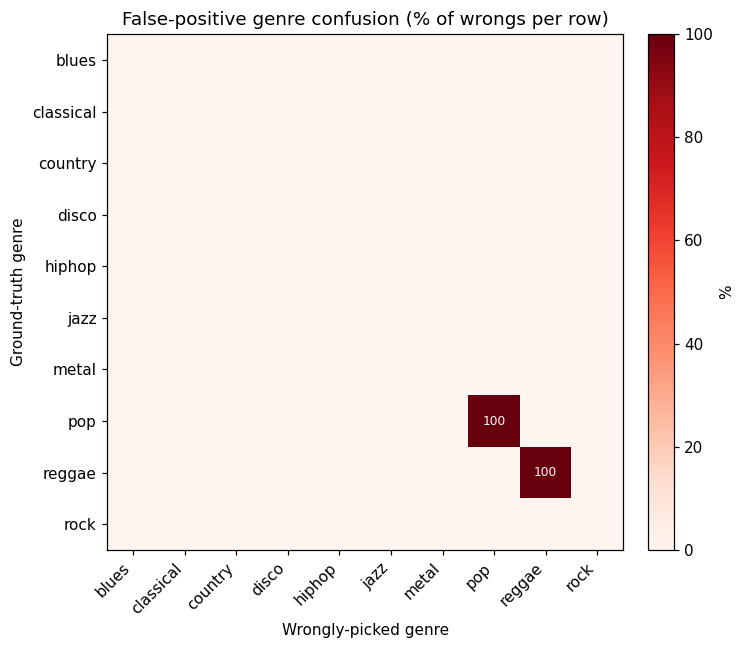

Of 87 false positives, 100.0% landed on the SAME genre as the ground truth.


In [14]:
wrong = df[df["outcome"] == "false_positive"].copy()
if len(wrong) == 0:
    print("No false positives to analyze.")
else:
    confusion = pd.crosstab(
        wrong["genre"], wrong["top_match_genre"], normalize="index"
    ) * 100
    confusion = confusion.reindex(index=sorted(df["genre"].unique()),
                                    columns=sorted(df["genre"].unique())).fillna(0)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(confusion.values, cmap="Reds", vmin=0, vmax=confusion.values.max())
    ax.set_xticks(np.arange(len(confusion.columns)))
    ax.set_xticklabels(confusion.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(confusion.index)))
    ax.set_yticklabels(confusion.index)
    ax.set_xlabel("Wrongly-picked genre")
    ax.set_ylabel("Ground-truth genre")
    ax.set_title("False-positive genre confusion (% of wrongs per row)")
    for i in range(confusion.shape[0]):
        for j in range(confusion.shape[1]):
            v = confusion.values[i, j]
            if v >= 1:
                ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                        color="black" if v < confusion.values.max() * 0.55 else "white",
                        fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="%")
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    same_genre = (wrong["genre"] == wrong["top_match_genre"]).mean() * 100
    print(f"Of {len(wrong):,} false positives, "
          f"{same_genre:.1f}% landed on the SAME genre as the ground truth.")

## 9. Summary table for the write-up
One row per (noise, SNR) condition with all four key metrics.

In [15]:
summary = (
    df.groupby(["aug_label", "aug_category", "db_severity"])
      .apply(lambda g: pd.Series({
          "n": len(g),
          "accuracy_%": (g["outcome"] == "correct").mean() * 100,
          "false_positive_%": (g["outcome"] == "false_positive").mean() * 100,
          "reject_%": (g["outcome"] == "reject").mean() * 100,
          "median_elapsed_s": g["elapsed_s"].median(),
      }), include_groups=False)
      .round(2)
)
summary.index.names = ["aug_type", "category", "db_severity"]

# Apply canonical row order (noise first, then transforms).
summary = summary.reindex(
    [(al, cat, lv)
     for al in AUG_LABEL_ORDER
     for cat in (["noise"] if al in ["Crowd Noise","Street Noise","White Noise"] else ["transform"])
     for lv in sorted(df[df["aug_label"]==al]["db_severity"].unique())]
)
summary

n  accuracy_%  false_positive_%  \
aug_type     category  db_severity                                        
Crowd Noise  noise     0            999.0       90.79               0.7   
                       10           999.0       91.29               0.9   
                       20           999.0       91.49               1.1   
Street Noise noise     0            999.0       89.79               0.5   
                       10           999.0       91.19               0.8   
                       20           999.0       91.49               0.9   
White Noise  noise     0            999.0       91.29               0.9   
                       10           999.0       91.49               1.0   
                       20           999.0       91.49               1.2   
Lo-Fi Filter transform 1            999.0        6.51               0.2   
                       2            999.0        7.71               0.2   
                       3            999.0        8.41               0.3   
Pitch Up     transform 1            999.0        0.00               0.0   
                       2            999.0        0.00               0.0   
                       3            999.0        0.00               0.0   
Pitch Down   transform 1            999.0        0.00               0.0   
                       2            999.0        0.00               0.0   
                       3            999.0        0.00               0.0   

                                    reject_%  median_elapsed_s  
aug_type     category  db_severity                              
Crowd Noise  noise     0                8.51              2.29  
                       10               7.81              2.59  
                       20               7.41              2.60  
Street Noise noise     0                9.71              3.08  
                       10               8.01              2.83  
                       20               7.61              2.80  
White Noise  noise     0                7.81              2.82  
                       10               7.51              2.93  
                       20               7.31              3.06  
Lo-Fi Filter transform 1               93.29              0.49  
                       2               92.09              0.38  
                       3               91.29              0.27  
Pitch Up     transform 1              100.00              2.54  
                       2              100.00              2.52  
                       3              100.00              2.38  
Pitch Down   transform 1              100.00              3.20  
                       2              100.00              2.71  
                       3              100.00              2.58